## Visualisation of mappings of AlphaFold and MD generated physicochemical properties of protein protein interaction PPI interfaces
The first plot shows the ROC curves which we obtain with
* A support vector classifier (SVC)
* A multi layer perceptron classifier (MLPC)
* A Gaussian process classifier (GPC)
* A random forest classifier (RFC)
* Four graph neural network architectures with different pooling strategies (GNNX, GNNM GNNS2S and GNNS)
The input data for classification were obtained from around 2000 PPIs which were predicted with AlphaFold 3 and further characterised and analysed by a molecular dynamical simulation. All assessed protein complexes have a solute carrier protein as one partner and are known to occuir in a protein comßlex with a second protein. The SLC complexes were predicted from mass spectrometry profiles which were collected and analysed by a large scale European initiative (RESOLUTE). The physicochemical features which enter the analyses in this work were extracted from AlphaFold 3 (AF3) and (mostly) from the results of a molecular dynamics (MD) simulation which was initialised with AF3 predicted spatial coordinates. By subsequent aggregation and transformation we obtain 64 (correlated) features. The GNNs were built from physicochemical properties of individual amino acids which constituted the resulting contacts and interaction interfaces. The GNNs can hence be considered providing a data driven aggregation and prediction model. All models were trained to discriminate the transmembran state of the SLC binding partner. Approximately 50% are transmembran proteins while the other half are not.  
## Results
* The visualised ROC cuirves clearly demonstrate that the physicochemical interface properties harbour information about the transmembran status. 
* The GNNs do not improve the prediction of th transmembrane status of the interfacing binding partner of the SLC.
* In comparison with using a simple aggregation of all prperties the GNN based embedding leads to larger Shannon channel capacity values. At the same time generalisation accuracy and the area under the ROC curve are slightly smaller. This observation hints that GNN training might have dsuffered from slight overfitting.    

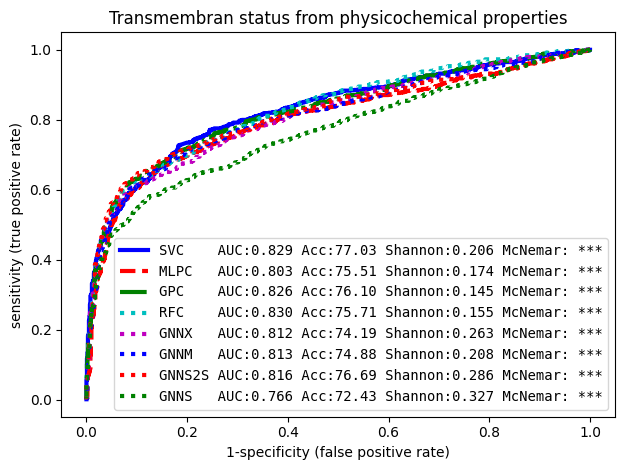

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# set the basepath to "one up"
basepath="../"
## set the path
import sys
sys.path.append(basepath+"ppi.lib/")
import ml_lib as mlib
# To produce ROC curves for all tested transmembran prediciton models
## we load the store from the default location 
## (mlib.defaultstore="../results/classmetrics.pkl") and create a visualisation
rocstore=mlib.readstore()
## print(rocstore)
mlib.store2roc(rocstore)
plt.savefig("../figures/physicochem2transmembran.png")
plt.show()

## Elucidating the relevance of individual physicochemical properties
To assess the information content in individual physicochemical properties about the transmembran status we used a number of different feature relevance metrics.
* The random forest classifier was built with three different purity criteria (gini index, entropy and log loss). Each of these metrics gives rise to relative importance valuies of all 64 input features. 
* By fitting a gaussian process classifier (GPC) on individual inoput features (plus intercept) and comparing the log marginal likelihood of the model with the log marginal likelihood of an intercept only GPC fitted to the binary class labels we opbtain feature specific Bayesian log odds values.
* By fitting property specific support vector classifiers we obtain four additional metrics of feature relevance: the area under the ROC curve (AUC), a generalisation accuracy (Gen. Acc.) a modified Shannon channel capacity (Shannon) and a McNemar p-value,

As is described in the methods section of the paper, we augment the eight different metrics to a combined rank metric. The motivation for this approach is to reduce the effects of noise and the methododological biases of individual feature relevance metrics in a combined verdict. To assess therobustness of the imortance ranking, we viualise in a second plot the rank uncertainty of the top 20 features by summarising the method specific rank positions for the top five places with pie charts. 

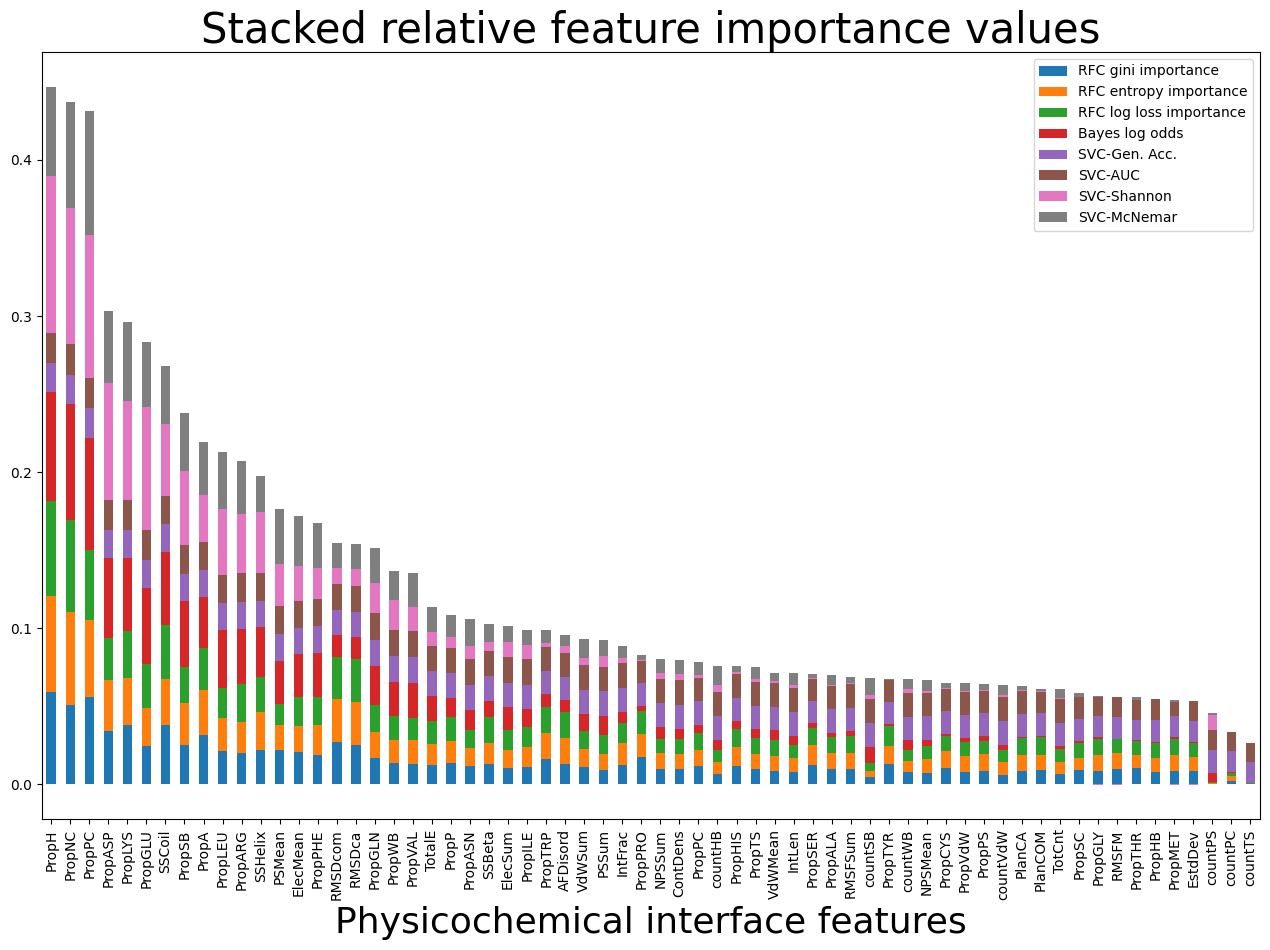

In [2]:
## generate evaluation plot
mapcolnams={'RFC_gini_importance':'RFC gini importance',
            'RFC_entropy_importance':'RFC entropy importance',
            'RFC_logloss_importance':'RFC log loss importance',
            'Bayes_logodds':'Bayes log odds',
            'SVC_acc':'SVC-Gen. Acc.',
            'SVC_auc':'SVC-AUC',
            'SVC_Shannon':'SVC-Shannon',
            'SVC_McNemar':'SVC-McNemar'}
## load the resut from the csv file
dfrm=pd.read_csv("../results/physicoftrs4transstate_eval.csv")
normdfrm=mlib.vals2sharedrank(dfrm)
## create a stacked importance plot
normdfrm=mlib.vals2sharedrank(dfrm)
normdfrm.set_index("names", drop=True, inplace=True)
## Improve the looks of the rank plot by changing the internal names to easier to read expressions
## read the feature name mapping to replace the feature names in all graphics with shorter accronyms 
mapdict=mlib.ftrnam2accronym()
normdfrm.rename(index=mapdict, inplace=True)
## map the names of all rank metric columns
normdfrm.rename(columns=mapcolnams, inplace=True)
ax=normdfrm.plot.bar(stacked=True, figsize=[6.4*2,4.8*2])
lblfntsz=26
ttlfsz=30
plt.xlabel("Physicochemical interface features", fontsize=lblfntsz)
plt.title("Stacked relative feature importance values", fontsize=ttlfsz)
plt.tight_layout()
plt.savefig("../figures/feature_importance.png")
plt.show()

## Metric specific rank variability as feature specific pie charts
The distinct drop in the above visualisation of the combined feature ranking after feture number 20 suggests to investigate the variability among the rankings of the top 20 features. The visuialisation below focusses on the situation at the top 5 rank positions.

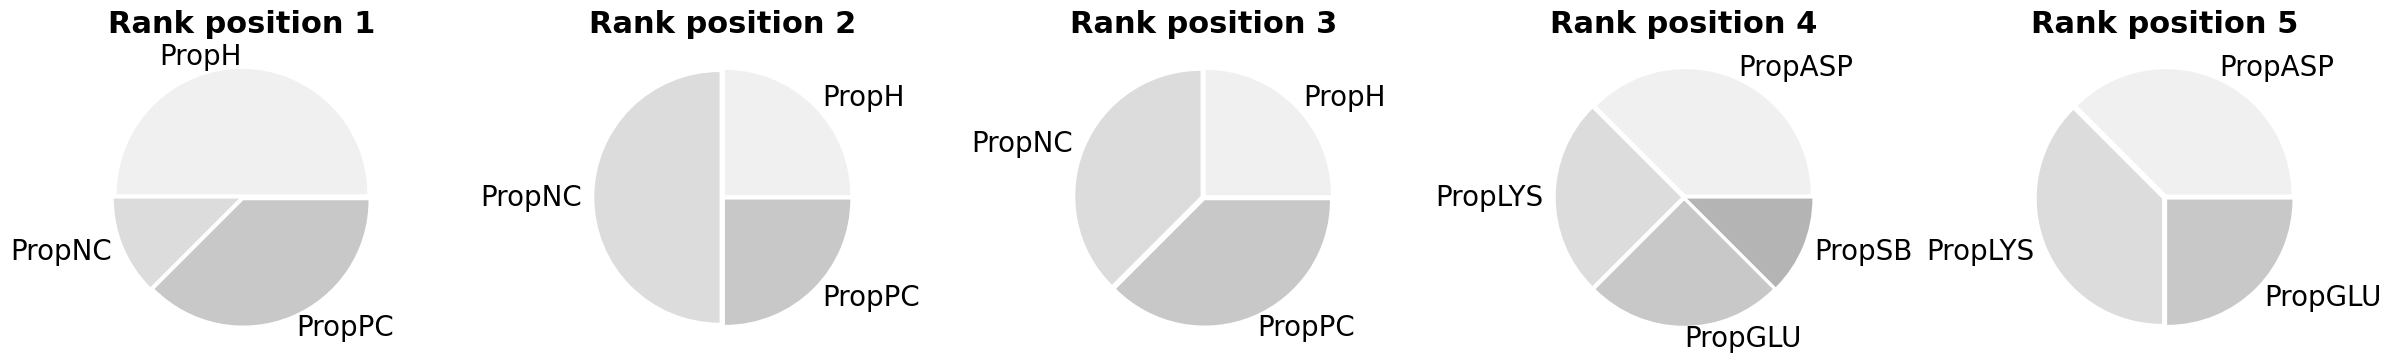

In [3]:
## rank variability as box plots
dfrm=pd.read_csv("../results/physicoftrs4transstate_eval.csv")
normdfrm=mlib.vals2sharedrank(dfrm)
## look at the variation of the metric specific ranks of the topnr features
## We visualise the variability as pie charts which illustrate the
## distribution of the topnr features at the highest five ranks.
## The motivation for setting topnr to 20 is the distinct drop between position 20 and 21.
## This drop hints that we have there an ellbow and the subsequent variation is less pronounced. 
topnr=20
topftrs=normdfrm.loc[:topnr, "names"].to_list()
dfrm.set_index("names", drop=False, inplace=True)
rankdf=mlib.vals2rankprob(dfrm.loc[topftrs,:], npos=5)
## to get the feature accronyms printed we apply the mapping to the index
rankdf.rename(index=mapdict, inplace=True)
colors=mlib.greyscale
colors.reverse()
fig=mlib.createpies(rankdf, colors=colors)
plt.tight_layout()
plt.savefig("../figures/feature_importance_variation.png")
plt.show()